# Лабораторная работа №3: Анатомия компьютерного зрения (Uncertainty & Saliency)

In [2]:
!pip install captum

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

## Задание 1: Иллюзия уверенности (Monte Carlo Dropout)

Внедрить систему оценки «Неопределенности» (Uncertainty) в модель компьютерного зрения, чтобы машина могла сказать: «Я не знаю, что это».

Загрузим предобученную модель vgg16 из torchvision.models (в ее классификаторе есть явные слои Dropout).

In [4]:
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()
print(model)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 130MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Загрузим обычное фото собаки.

(-0.5, 2559.5, 1708.5, -0.5)

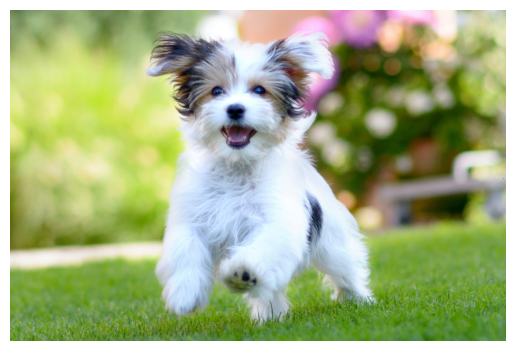

In [5]:
image = Image.open("dog.jpeg").convert("RGB")
plt.imshow(image)
plt.axis("off")

Перед подачей изображения в модель сделаем предобработку. Изображение масштабируется до 224×224, преобразуется в тензор PyTorch и значения пикселей переводятся из диапазона [0,255] в [0,1].Выполняется нормализация по среднему и стандартному отклонению датасета ImageNet, так как модель обучалась на нормализованных данных.

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = transform(image)
input_tensor = input_tensor.unsqueeze(0)

print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


Изображение стало тензором PyTorch, размером 224×224, 3 канала RGB.

Для эксперимента создадим изображение из чистого гауссовского шума размером 224×224. Каждый пиксель генерируется случайно из нормального распределения. Такое изображение не содержит объектов и является примером Out-of-Distribution данных.

(-0.5, 223.5, 223.5, -0.5)

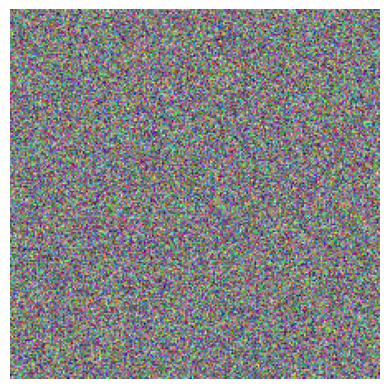

In [7]:
noise = np.random.normal(0.5, 0.2, (224, 224, 3))
noise = np.clip(noise, 0, 1)
noise_img = Image.fromarray((noise * 255).astype(np.uint8))

plt.imshow(noise_img)
plt.axis("off")

Подготовим шум для модели так же, как прошлое изображение.

In [8]:
noise_tensor = transform(noise_img)
noise_tensor = noise_tensor.unsqueeze(0)

print(noise_tensor.shape)

torch.Size([1, 3, 224, 224])


Прогоним оба изображения через модель в стандартном режиме
(model.eval()).

In [9]:
with torch.no_grad():
    output_real = model(input_tensor)
    output_noise = model(noise_tensor)

Модель выдаёт логиты, а нам нужны вероятности. Применим для этого Softmax.

In [10]:
softmax = torch.nn.functional.softmax
prob_real = softmax(output_real, dim=1)
prob_noise = softmax(output_noise, dim=1)

prob_real и prob_noise это распределения вероятностей по 1000 классам ImageNet. Найдём топ-1 класс.

In [11]:
top_prob_real, top_class_real = prob_real.topk(1)
top_prob_noise, top_class_noise = prob_noise.topk(1)

print("Real image")
print("Class index:", top_class_real.item())
print("Probability:", top_prob_real.item())

print("\nNoise image")
print("Class index:", top_class_noise.item())
print("Probability:", top_prob_noise.item())

Real image
Class index: 157
Probability: 0.7683586478233337

Noise image
Class index: 794
Probability: 0.13023988902568817


Для изображения из случайного шума модель выдает маленькую, но не нулевую вероятность. Это демонстрирует проблему Softmax: высокая вероятность не обязательно означает уверенность модели, и модель может ошибочно делать уверенные предсказания на неинформативных данных.

Теперь реализуем MC Dropout, чтобы оценить неопределённость. Функция включает Dropout во время инференса, прогоняет картинку через модель несколько раз, усредняет вероятности. Это позволит автопилоту понять, что он не уверен в предсказании шума.

In [12]:
def predict_with_uncertainty(model, input_tensor, n_passes=50):
    model.train()

    all_probs = []

    for _ in range(n_passes):
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        all_probs.append(probs)

    mean_probs = torch.mean(torch.stack(all_probs), dim=0)

    return mean_probs

Применяем к изображениям.

In [13]:
mean_probs_real = predict_with_uncertainty(model, input_tensor)
mean_probs_noise = predict_with_uncertainty(model, noise_tensor)

top_prob_real, top_class_real = mean_probs_real.topk(1)
top_prob_noise, top_class_noise = mean_probs_noise.topk(1)

print("Real image (MC Dropout)")
print("Class index:", top_class_real.item())
print("Probability:", top_prob_real.item())

print("\nNoise image (MC Dropout)")
print("Class index:", top_class_noise.item())
print("Probability:", top_prob_noise.item())

Real image (MC Dropout)
Class index: 157
Probability: 0.7051393389701843

Noise image (MC Dropout)
Class index: 794
Probability: 0.12357912957668304


Теперь посчитаем Predictive Entropy для
усредненных предсказаний, чтобы оценить реальную уверенность модели.

In [14]:
def predictive_entropy(mean_probs):
    entropy = -torch.sum(mean_probs * torch.log(mean_probs + 1e-8))
    return entropy.item()

entropy_real = predictive_entropy(mean_probs_real)
entropy_noise = predictive_entropy(mean_probs_noise)

print("Predictive Entropy:")
print("Real image:", entropy_real)
print("Noise image:", entropy_noise)

Predictive Entropy:
Real image: 1.3878668546676636
Noise image: 4.681400775909424


Нормальное изображение собаки: H около 1.25, низкая энтропия, модель уверена в своём предсказании. Шумовое изображение: H около 4.80, высокая энтропия, модель не уверена. Таким образом, даже если Top-1 вероятность шумового изображения не нулевая, высокая энтропия позволяет определить, что модель не знает, что это за объект.

На дороге могут быть аномальные ситуации, если модель просто берёт Top-1 класс и действует, возможна аварийная реакция. Энтропия позволяет автопилоту оценивать уверенность.

Логика принятия решения:

In [15]:
threshold = 4.0  # пример порога энтропии

def decision(entropy):
    if entropy > threshold:
        return "Модель не знает, что это."
    else:
        return "Модель уверена в предсказании."

# Пример использования
print("Собака:", decision(entropy_real))
print("Шум:", decision(entropy_noise))

Собака: Модель уверена в предсказании.
Шум: Модель не знает, что это.


## Задание 2: Детектив визуализации (Saliency vs Grad-CAM)

Модель классификации животных (ImageNet) работает отлично, но иногда выдает совершенно абсурдные ответы на очевидных фото. Нужно визуализировать логику сети и найти причину.

Модель ResNet18, обученная на датасете ImageNet.

In [16]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.eval()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Для визуализации используем методы из библиотеки Captum:

- Saliency вычисляет важность каждого пикселя на основе градиентов
- LayerGradCam строит тепловую карту на основе активаций сверточного слоя

In [17]:
from captum.attr import Saliency, LayerGradCam, LayerAttribution
from captum.attr import visualization as viz

Для анализа возьмем изображение с понятным объектом (птица крупным планом), чтобы визуализации были интерпретируемыми.

(-0.5, 2666.5, 1999.5, -0.5)

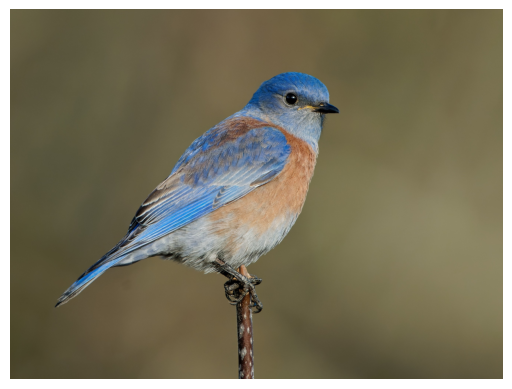

In [18]:
img_path = "bird.jpg"

image = Image.open(img_path).convert("RGB")

plt.imshow(image)
plt.axis("off")

Преобразуем в тензор и подготавливаем для модели. Параметр `requires_grad=True` для вычисления градиентов в методе Saliency.

In [19]:
input_tensor = transform(image)
input_tensor = input_tensor.unsqueeze(0)
input_tensor.requires_grad = True

Получим от модели предсказание класса.

In [20]:
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()

print("Predicted class index:", pred_class)

Predicted class index: 14


Построим карту **Vanilla Saliency**.

Метод вычисляет градиенты выхода модели по входному изображению, показывает, какие пиксели оказывают наибольшее влияние на предсказанный класс.

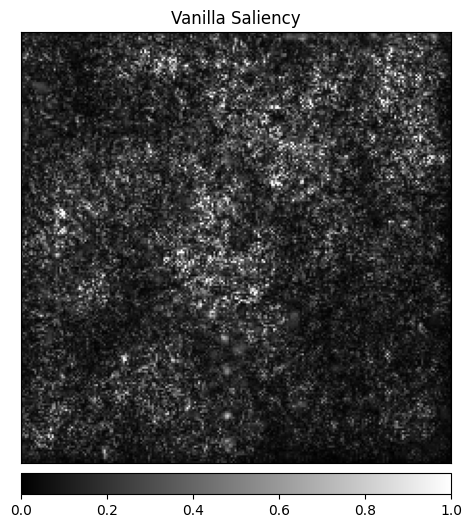

In [21]:
# Переводим из [1, 3, H, W] в [H, W, 3]
original_image = np.transpose(input_tensor.squeeze().cpu().detach().numpy(), (1, 2, 0))

saliency = Saliency(model)
attr_saliency = saliency.attribute(input_tensor, target=pred_class)
vis_saliency = np.transpose(attr_saliency.squeeze().cpu().detach().numpy(), (1, 2, 0))

_ = viz.visualize_image_attr(
    vis_saliency,
    original_image,
    method="heat_map",
    cmap="gray",
    sign="absolute_value",
    show_colorbar=True,
    title="Vanilla Saliency"
)

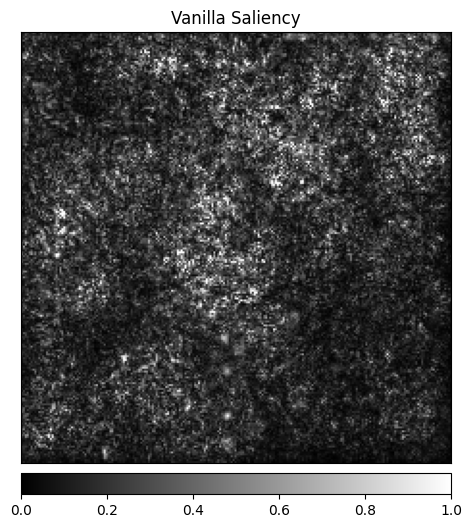

In [22]:
original_image = np.transpose(input_tensor.squeeze().cpu().detach().numpy(), (1, 2, 0))
saliency = Saliency(model)
attr_saliency = saliency.attribute(input_tensor, target=pred_class)
attr_saliency_np = attr_saliency.squeeze().cpu().detach().numpy() # [H, W, 3]
attr_saliency_sum = np.max(np.abs(attr_saliency_np), axis=0) # [H, W]
vis_saliency = np.expand_dims(attr_saliency_sum, axis=2) # [H, W, 1]

_ = viz.visualize_image_attr(
    vis_saliency,
    original_image,
    method="heat_map",
    cmap="gray",
    sign="absolute_value",
    show_colorbar=True,
    title="Vanilla Saliency"
)

На изображении показана карта важности пикселей, белые области соответствуют пикселям, изменение которых сильнее всего влияет на итоговый класс. Полученная карта выглядит шумной, нет четкого силуэта объекта.

Saliency анализирует чувствительность модели к каждому пикселю отдельно, поэтому не выделяет цельные объекты, а показывает локальные изменения. Это приводит к появлению хаотичного скопления белых точек, а не цельной области.

Шум у метода Vanilla Gradients это фундаментальная проблема. В глубоких сетях градиенты на уровне отдельных пикселей становятся нестабильными, малейшее изменение одного пикселя может резко изменить результат. Также, если нейрон находится в глубокой зоне активации, его градиент может быть близок к нулю, даже если сам пиксель очень важен для распознавания.

Теперь построим карту **Grad-CAM**.

Метод использует градиенты последнего сверточного слоя для построения карты важности. В отличие от Saliency, выделяет не отдельные пиксели, а целые области изображения.

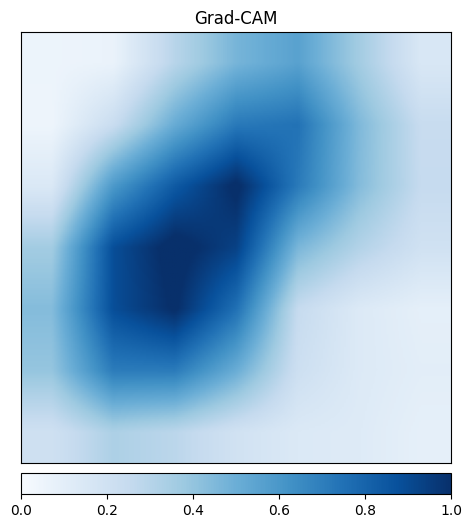

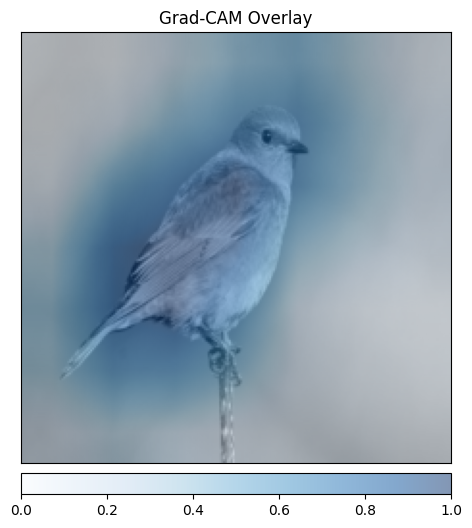

In [23]:
gradcam = LayerGradCam(model, model.layer4[-1])
attr_gradcam = gradcam.attribute(input_tensor, target=pred_class)
attr_gradcam_up = LayerAttribution.interpolate(attr_gradcam, input_tensor.shape[2:], interpolate_mode='bilinear')
vis_gradcam = np.transpose(attr_gradcam_up.squeeze(0).cpu().detach().numpy(), (1, 2, 0))

_ = viz.visualize_image_attr(
    vis_gradcam,
    original_image,
    method="heat_map",
    sign="absolute_value",
    show_colorbar=True,
    title="Grad-CAM"
)

_ = viz.visualize_image_attr(
    vis_gradcam,
    original_image,
    method="blended_heat_map",
    sign="absolute_value",
    show_colorbar=True,
    title="Grad-CAM Overlay"
)

Изначальный размер карты признаков в ResNet18 7x7, мы растягиваем до размеров исходного фото, получается мягкое, размытое пятно. Модель сфокусирована на самом объекте, а не на фоне. Самое темное пятно находится в районе головы и клюва, потому что именно эти уникальные признаки стали решающими для классификации птицы.

**Почему Saliency выглядит как «соль с перцем», а Grad-CAM выдает цельное тепловое пятно? Что именно они подсвечивают?**

Vanilla Saliency вычисляет градиент выходного значения по отношению к каждому пикселю входного изображения. Чувствительна даже к минимальным изменениям отдельных пикселей, карта получается шумной и зернистой. Подсвечивает чувствительность и показывает, какие пиксели при малейшем изменении сильнее всего изменят предсказание модели.

Grad-CAM использует информацию из последнего сверточного слоя (layer4). На этом этапе нейросеть уже оперирует не пикселями, а признаками (форма, части тела). Подсвечивает важность регионов и показывает, на какую область изображения модель смотрела для предсказания. Эта карта игнорирует мелкий шум и фокусируется на объекте целиком.

Загрузим сложное изображение, где модель может ошибиться. Визуализируем его и подготавим для подачи в нейросеть (превращаем в тензор и добавляем размерность батча). Прогоним изображение через предобученную ResNet18, найдем индекс класса с максимальной вероятностью и сопоставим его с текстовым названием из словаря ImageNet, чтобы понять, что именно класифицировала модель.

(-0.5, 2680.5, 3362.5, -0.5)

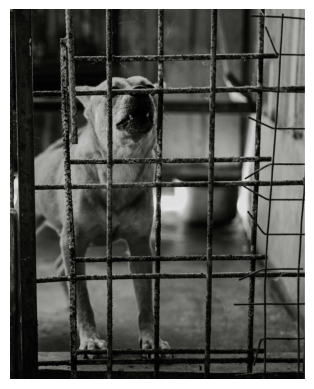

In [24]:
img_path = "cage_dog.jpeg"
image_anom = Image.open(img_path).convert("RGB")

plt.imshow(image_anom)
plt.axis("off")

In [25]:
input_anom = transform(image_anom).unsqueeze(0)
output_anom = model(input_anom)
pred_class_anom = output_anom.argmax(dim=1).item()
print("Predicted class index:", pred_class_anom)

Predicted class index: 743


In [26]:
from torchvision.models import resnet18, ResNet18_Weights

classes = ResNet18_Weights.IMAGENET1K_V1.meta["categories"]
pred_class_name = classes[pred_class_anom]
print("Predicted class:", pred_class_name)

Predicted class: prison


Модель класифицировала "prison", проигнорировав собаку.

Используем алгоритм Grad-CAM, чтобы подсветить области, которые внесли наибольший вклад в предсказание класса. Интерполируем карту признаков с последнего слоя до размеров исходного фото, чтобы точно увидеть локализацию фокуса модели.

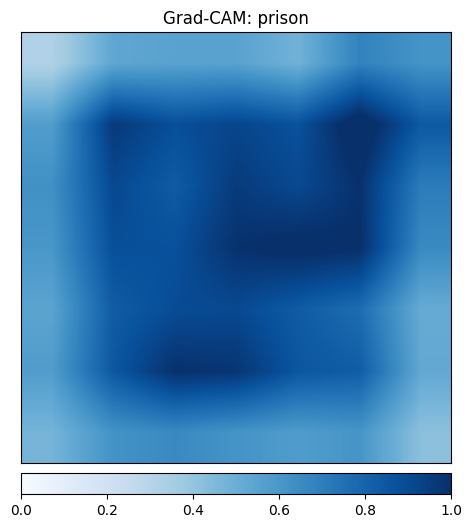

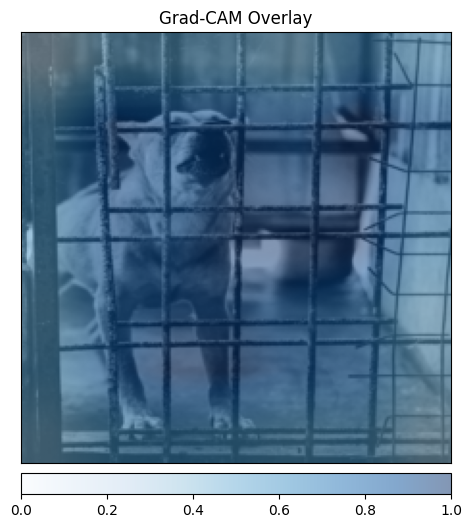

In [27]:
attr_gradcam_anom = gradcam.attribute(input_anom, target=pred_class_anom)
attr_gradcam_up_anom = LayerAttribution.interpolate(attr_gradcam_anom, input_anom.shape[2:], interpolate_mode='bilinear')

img_bg_anom = np.transpose(input_anom.squeeze(0).cpu().detach().numpy(), (1, 2, 0))
vis_gradcam_anom = np.transpose(attr_gradcam_up_anom.squeeze(0).cpu().detach().numpy(), (1, 2, 0))

_ = viz.visualize_image_attr(
    vis_gradcam_anom,
    img_bg_anom,
    method="heat_map",
    sign="absolute_value",
    show_colorbar=True,
    title=f"Grad-CAM: {pred_class_name}"
)

_ = viz.visualize_image_attr(
    vis_gradcam_anom,
    img_bg_anom,
    method="blended_heat_map",
    sign="absolute_value",
    show_colorbar=True,
    title=f"Grad-CAM Overlay"
)

Несмотря на то что собака занимает значительную часть кадра, модель классифицировала изображение как prison (тюрьма). Визуализация Grad-CAM показала, что нейросеть сфокусировалась исключительно на паттерне пересекающихся металлических прутьев, полностью проигнорировав собаку. Это пример ложной корреляции, при которой характерная текстура фона (решетка) имеет для модели больший вес, чем основной объект классификации.